In [9]:
import pandas as pd
import matplotlib.pyplot as plt

!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Path to dataset files:", path)



zsh:1: command not found: pip


100%|██████████| 653M/653M [00:44<00:00, 15.5MB/s] 

Extracting files...


Path to dataset files: /Users/ilgaz/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13


In [27]:
import os
import pandas as pd

path = "/Users/ilgaz/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13"

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
full_csv_path = os.path.join(path, csv_file)

print(full_csv_path)

df = pd.read_csv(full_csv_path)



/Users/ilgaz/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13/US_Accidents_March23.csv


KeyboardInterrupt: 

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Duration(min)', 'Duration', 'start_year',
       'start_month', 'start_day', 'start_hour', 'start_minute',
       'start_dayofweek', 'start_day_name', 'start_month_name',
       'start_quarter', 'start_weekofyear', 'is_weekend', 'is_weekday',
       'part_of_day', 'is_morning_rus

In [35]:
import pandas as pd
import numpy as np

# make sure datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

# -------------------------
# Basic calendar features
# -------------------------
df['start_year'] = df['Start_Time'].dt.year
df['start_month'] = df['Start_Time'].dt.month
df['start_day'] = df['Start_Time'].dt.day
df['start_hour'] = df['Start_Time'].dt.hour
df['start_minute'] = df['Start_Time'].dt.minute
df['start_dayofweek'] = df['Start_Time'].dt.dayofweek   # Monday=0, Sunday=6
df['start_day_name'] = df['Start_Time'].dt.day_name()
df['start_month_name'] = df['Start_Time'].dt.month_name()
df['start_quarter'] = df['Start_Time'].dt.quarter
df['start_weekofyear'] = df['Start_Time'].dt.isocalendar().week.astype('Int64')

# -------------------------
# Weekend / weekday
# -------------------------
df['is_weekend'] = df['start_dayofweek'].isin([5, 6]).astype(int)
df['is_weekday'] = df['start_dayofweek'].isin([0, 1, 2, 3, 4]).astype(int)

# -------------------------
# Time of day buckets
# -------------------------
def get_part_of_day(hour):
    if pd.isna(hour):
        return np.nan
    elif 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['part_of_day'] = df['start_hour'].apply(get_part_of_day)

# -------------------------
# Rush hour features
# -------------------------
df['is_morning_rush'] = df['start_hour'].between(7, 9).astype(int)
df['is_evening_rush'] = df['start_hour'].between(16, 18).astype(int)
df['is_rush_hour'] = ((df['is_morning_rush'] == 1) | (df['is_evening_rush'] == 1)).astype(int)

# -------------------------
# Night / business hour
# -------------------------
df['is_night'] = df['start_hour'].isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
df['is_business_hours'] = df['start_hour'].between(9, 17).astype(int)

# -------------------------
# Season
# -------------------------
def get_season(month):
    if pd.isna(month):
        return np.nan
    elif month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['start_month'].apply(get_season)

# -------------------------
# Duration from Start and End
# -------------------------
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

# optional cleaning
df.loc[df['duration_min'] < 0, 'duration_min'] = np.nan

# -------------------------
# Cyclical encoding
# very useful for modeling
# -------------------------
df['hour_sin'] = np.sin(2 * np.pi * df['start_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['start_hour'] / 24)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['start_dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['start_dayofweek'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['start_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['start_month'] / 12)

In [32]:
# Missing % by year for ALL columns
missing_by_year = df.groupby('start_year').apply(lambda x: x.isna().mean() * 100)
missing_by_year

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,is_night,is_business_hours,season,duration_min,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos
start_year,,,,,,,,,,,,,,,,,,,,,
2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.489878,68.489878,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.338890,76.338890,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.247992,81.247992,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.566402,72.566402,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.711081,40.711081,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.119808,32.119808,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.730181,18.730181,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Ensure datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

# Create duration in minutes
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['Duration']


0          314.000000
1           30.000000
2           30.000000
3           30.000000
4           30.000000
              ...    
7728389     28.600000
7728390     26.883333
7728391     28.466667
7728392     29.350000
7728393     29.416667
Name: Duration, Length: 7728394, dtype: float64

# Cleaning

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x10eb08250> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

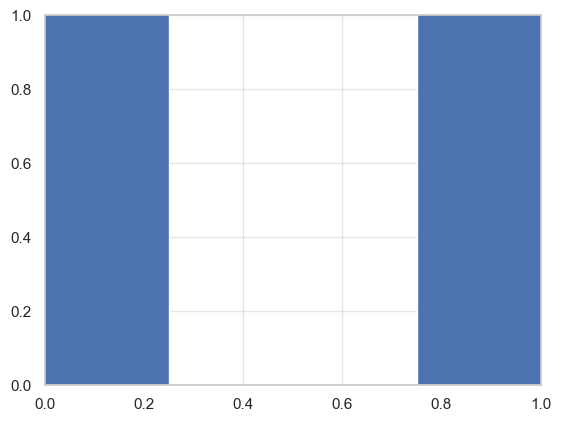

In [33]:
# Remove negative durations (data errors)
df = df[df['Duration(min)'] >= 0]

# Optional: cap extreme outliers (e.g., > 1 day)
df = df[df['Duration(min)'] <= 1440]



<Axes: ylabel='Frequency'>

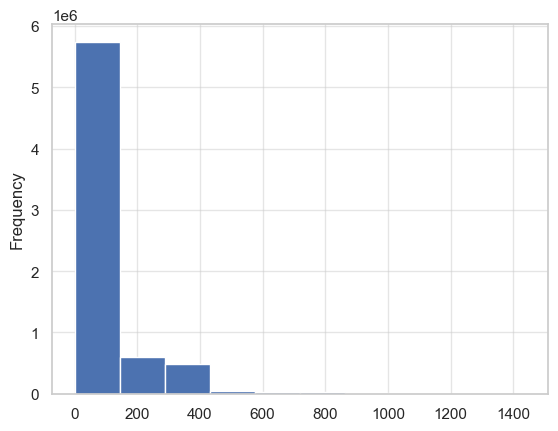

In [34]:
df['Duration'].plot(kind='hist')

In [ ]:
df.loc[:, ['y']]

# NA values in %

In [17]:
df.isna().sum()/len(df) * 100

ID                        0.000000
Source                    0.000000
Severity                  0.000000
Start_Time                0.000000
End_Time                  0.000000
Start_Lat                 0.000000
Start_Lng                 0.000000
End_Lat                  44.029355
End_Lng                  44.029355
Distance(mi)              0.000000
Description               0.000065
Street                    0.140637
City                      0.003274
County                    0.000000
State                     0.000000
Zipcode                   0.024779
Country                   0.000000
Timezone                  0.101030
Airport_Code              0.292881
Weather_Timestamp         1.555666
Temperature(F)            2.120143
Wind_Chill(F)            25.865904
Humidity(%)               2.253301
Pressure(in)              1.820288
Visibility(mi)            2.291524
Wind_Direction            2.267043
Wind_Speed(mph)           7.391355
Precipitation(in)        28.512858
Weather_Condition   

In [8]:
df['Source'].unique()

<StringArray>
['Source2', 'Source3', 'Source1']
Length: 3, dtype: str

/var/folders/_s/rr3vzrls4vn48gchgysgs49c0000gn/T/ipykernel_76146/3101422013.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


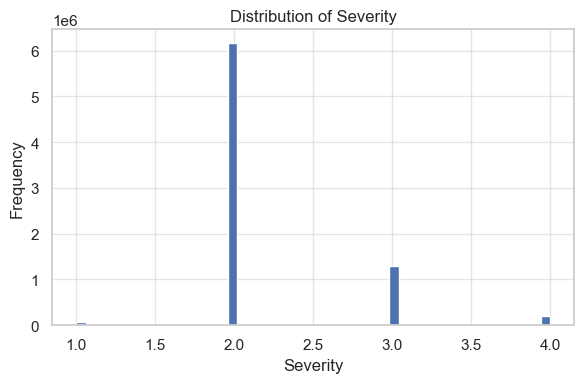

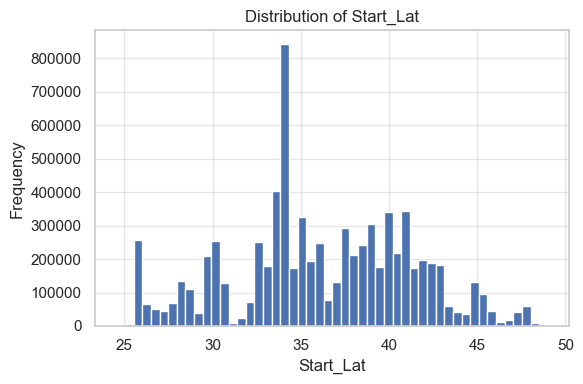

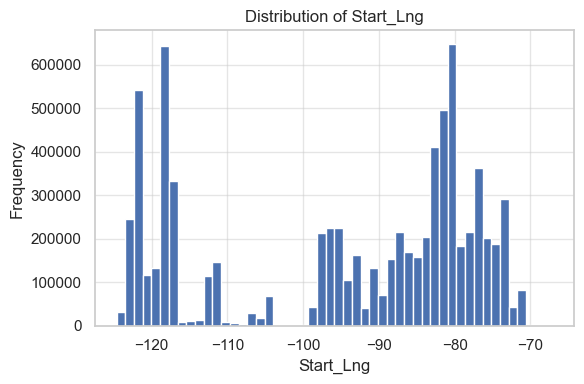

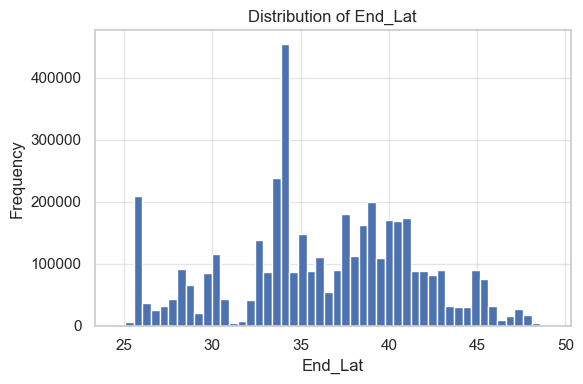

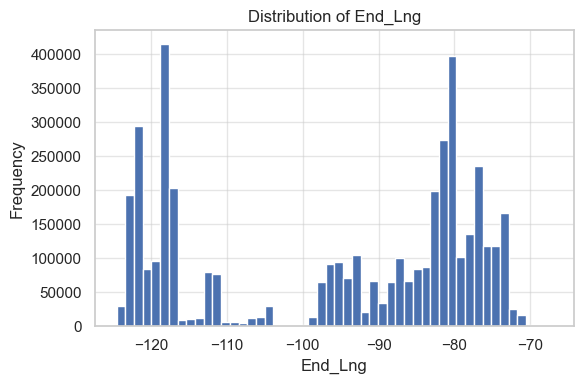

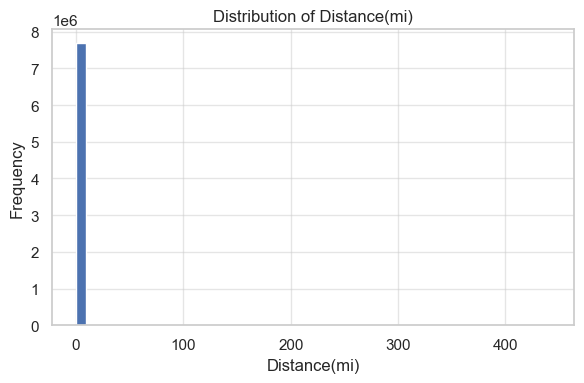

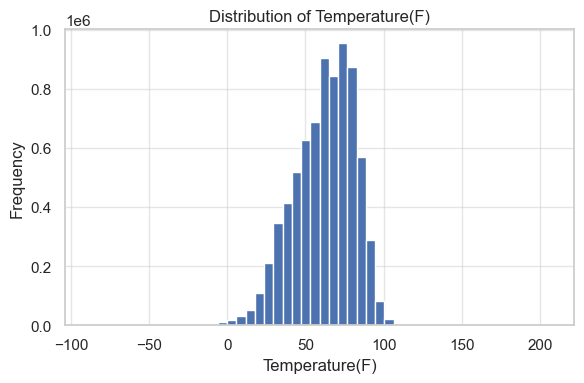

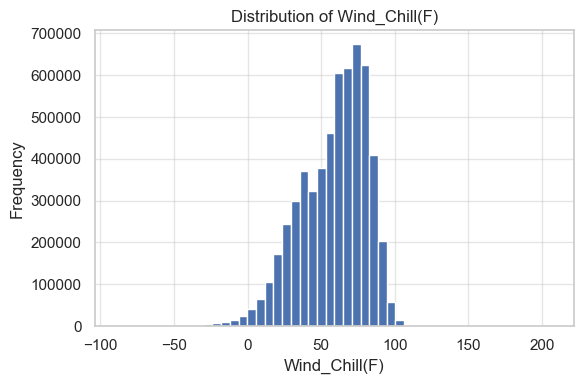

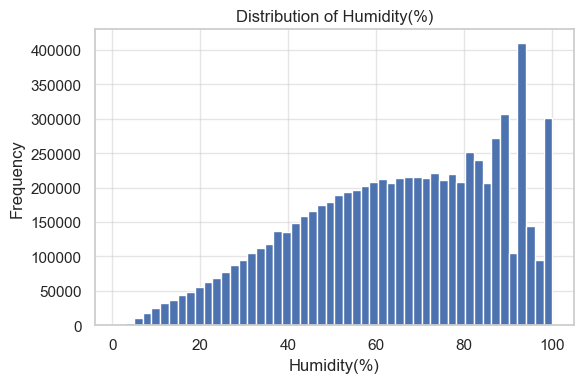

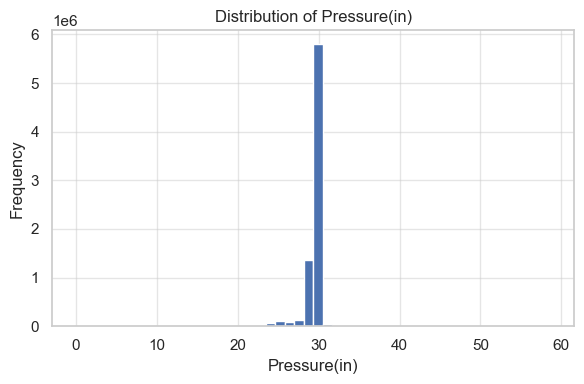

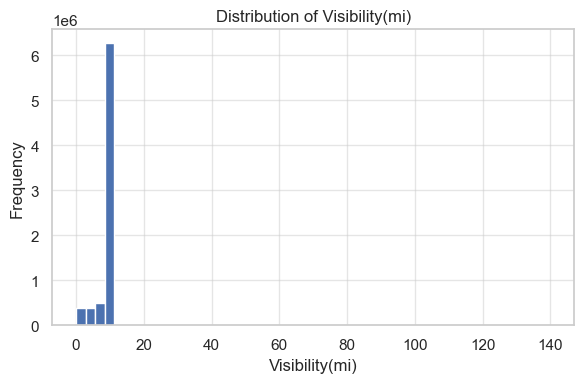

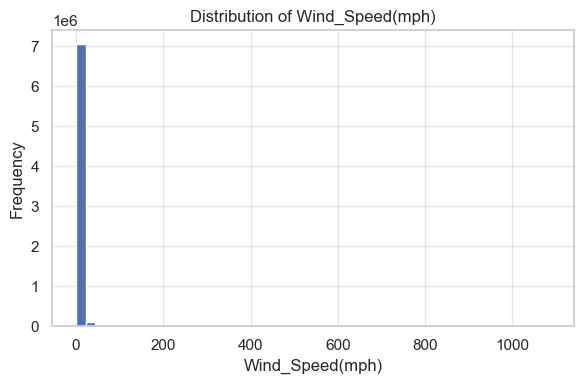

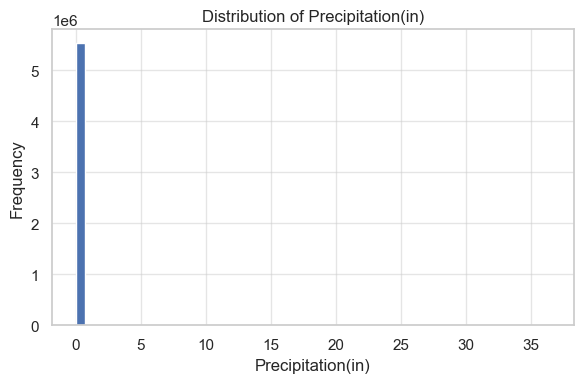

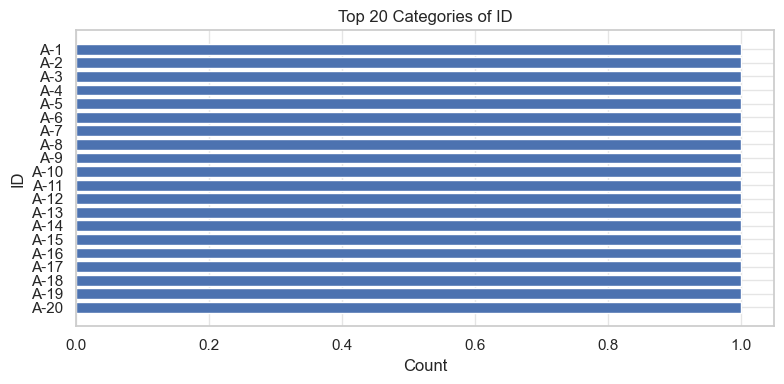

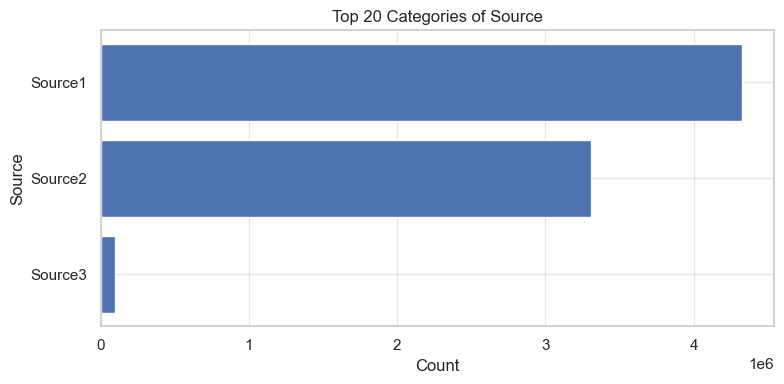

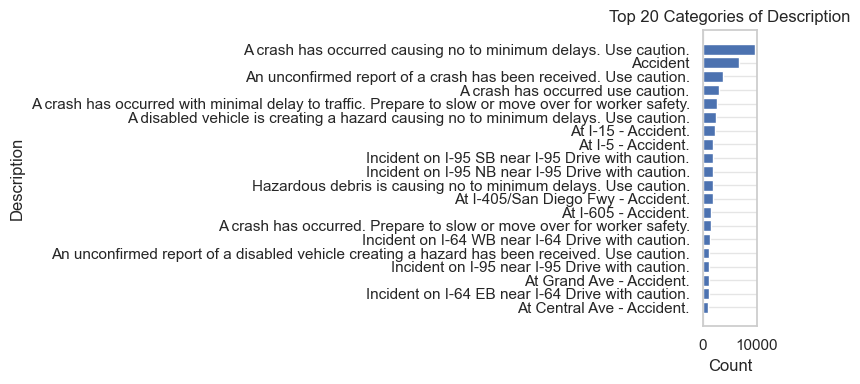

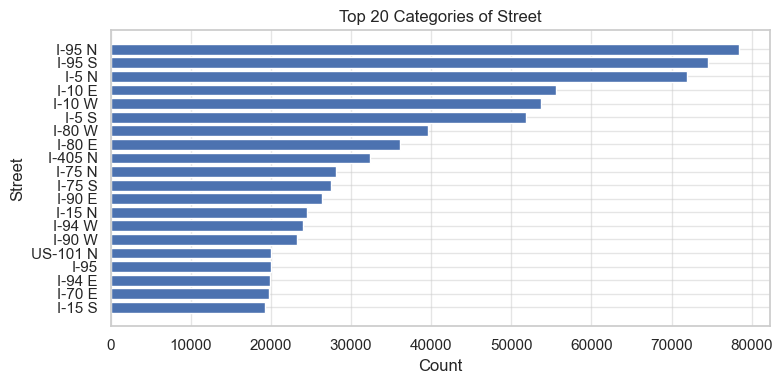

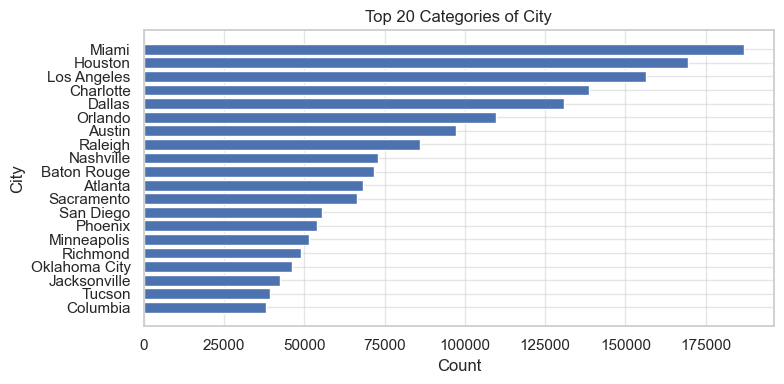

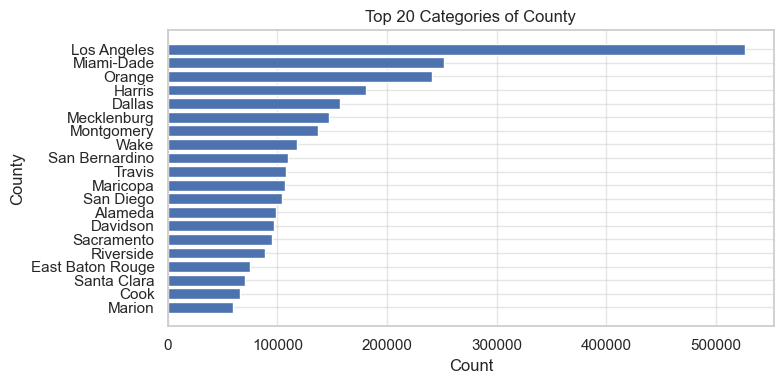

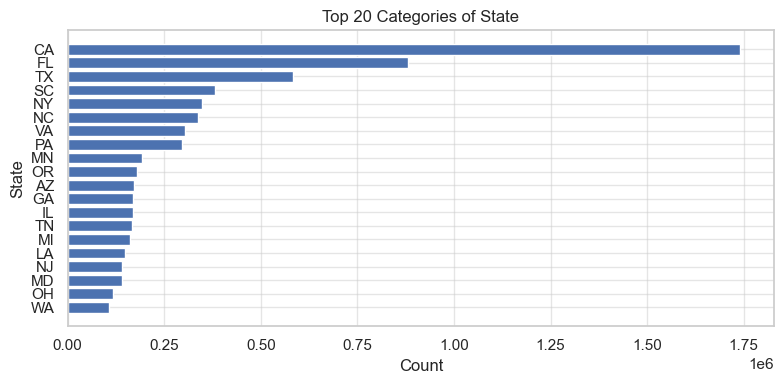

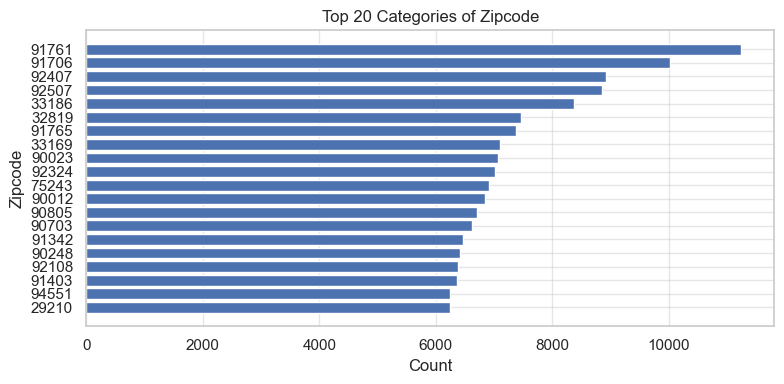

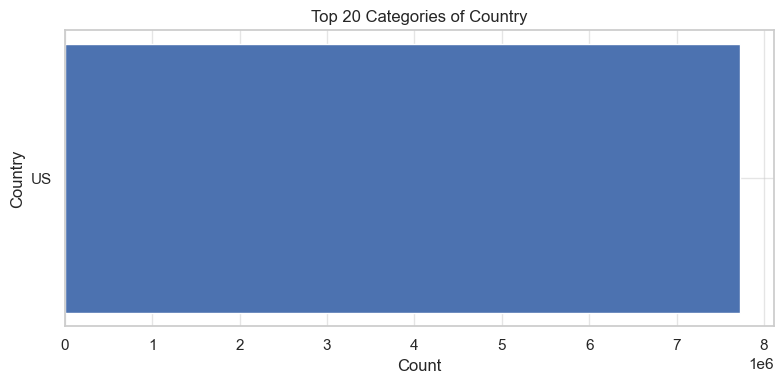

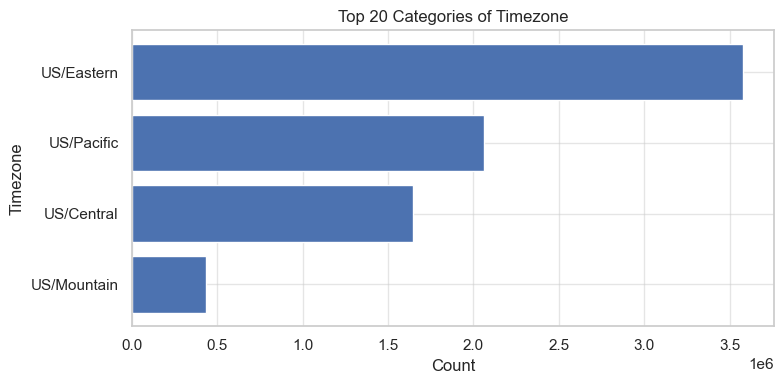

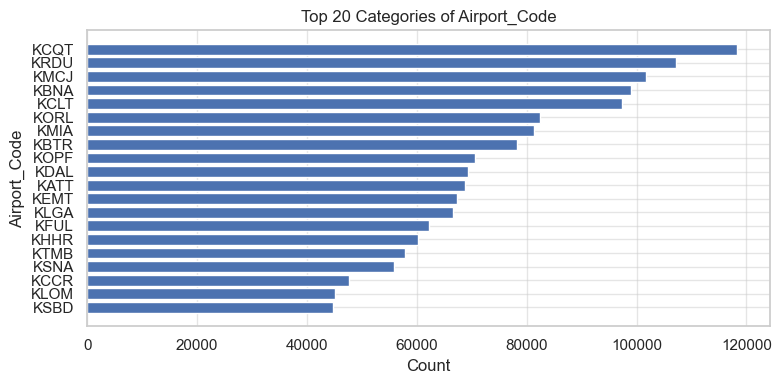

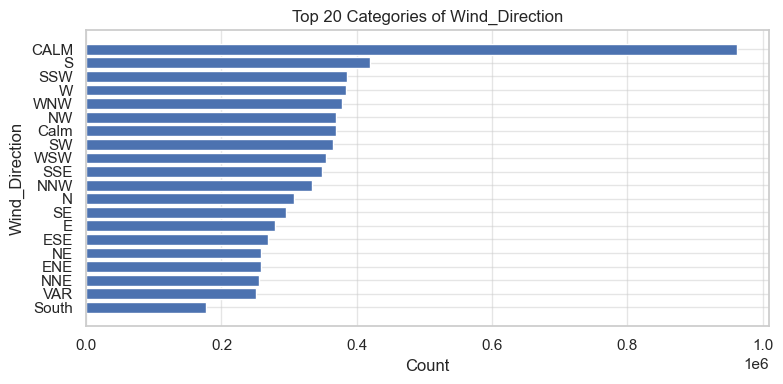

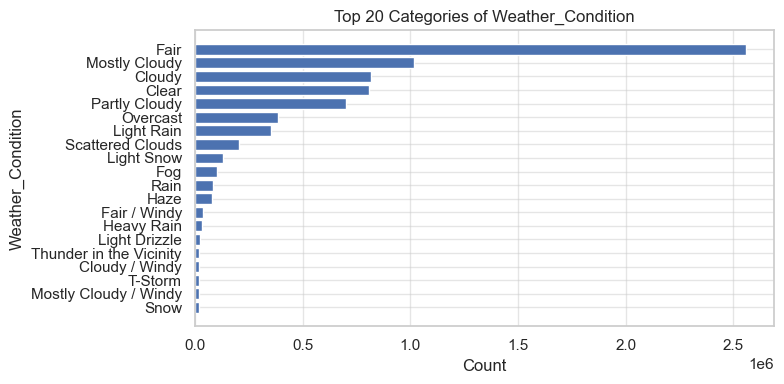

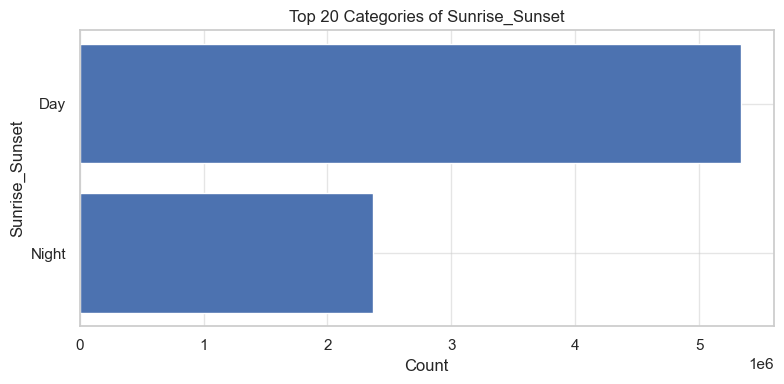

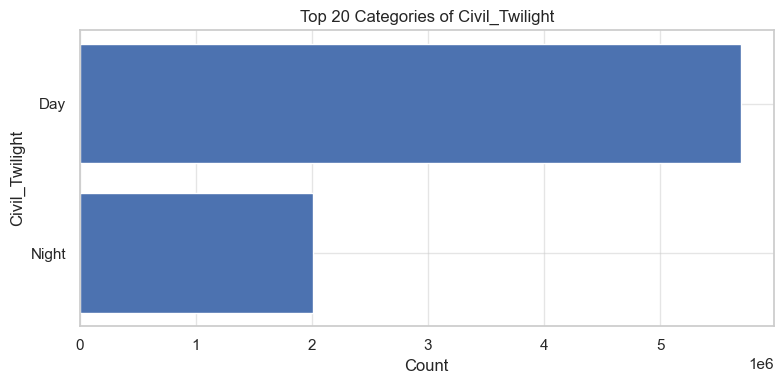

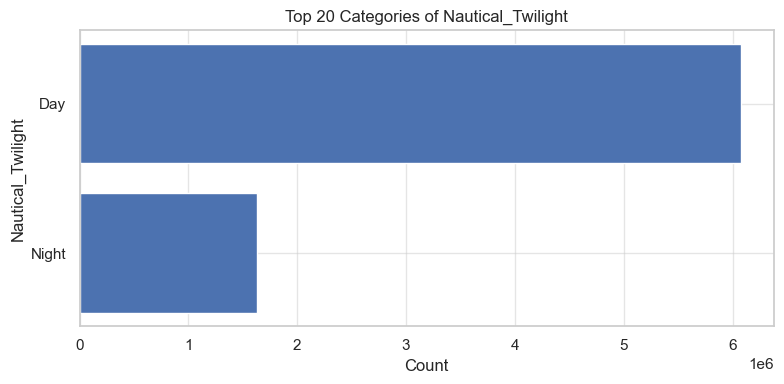

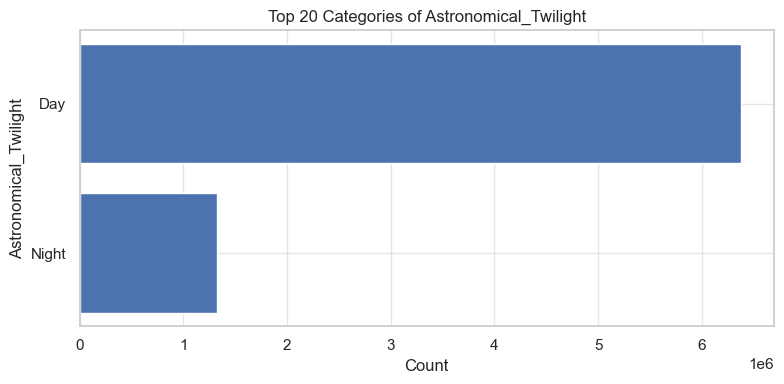

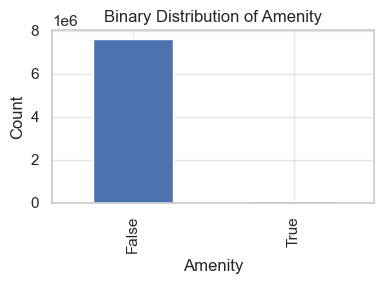

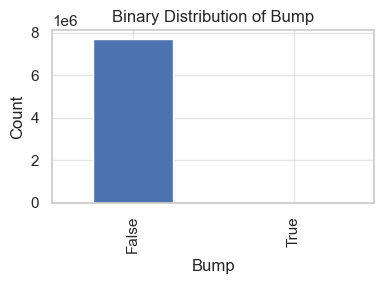

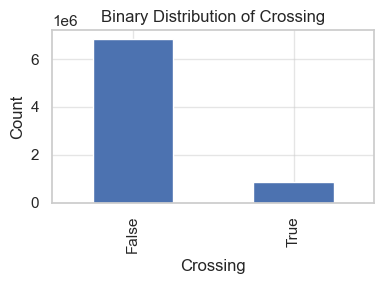

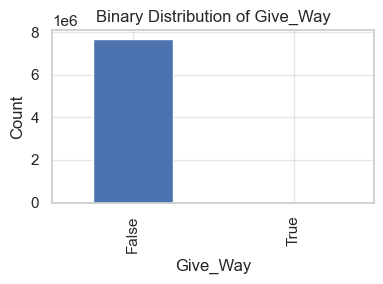

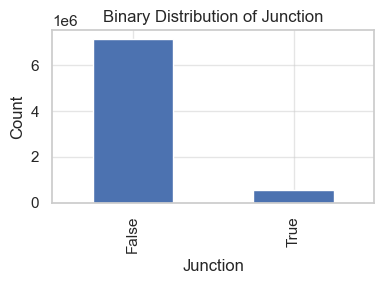

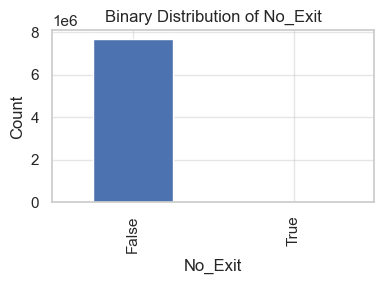

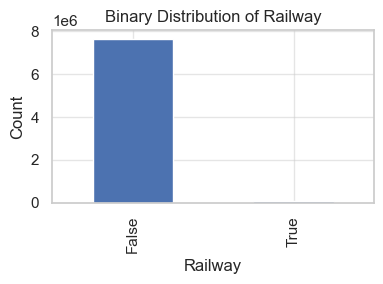

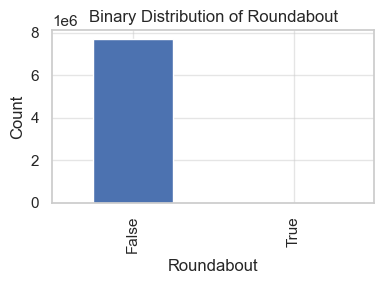

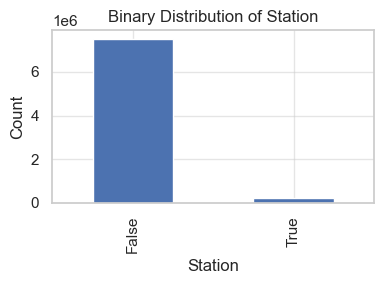

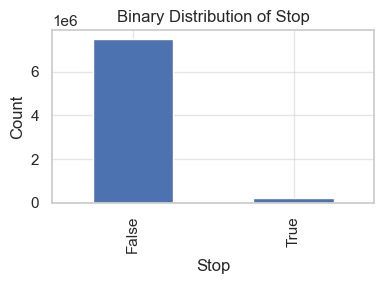

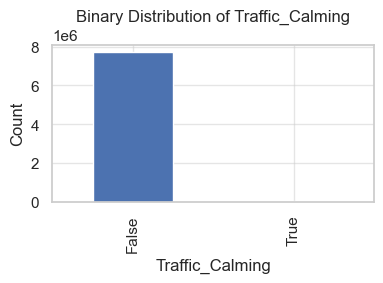

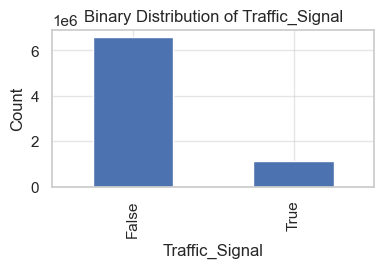

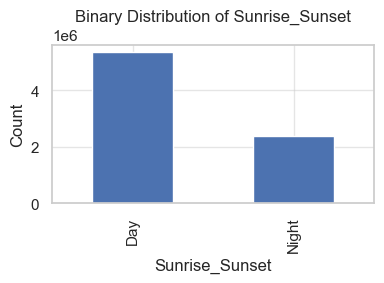

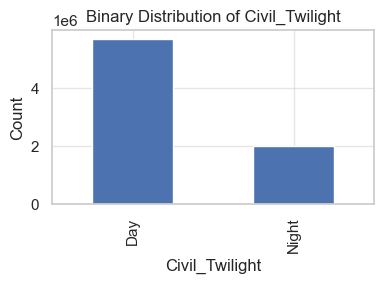

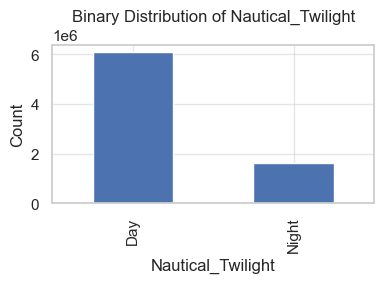

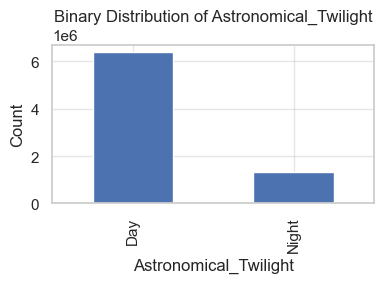

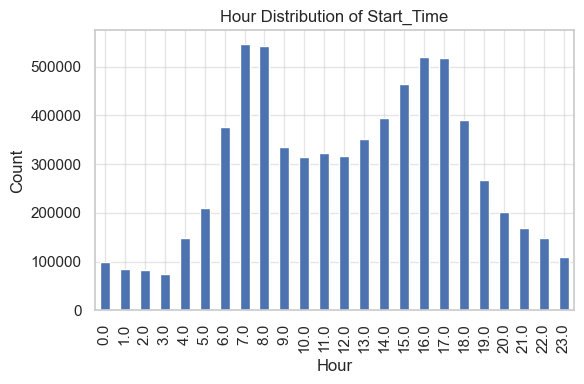

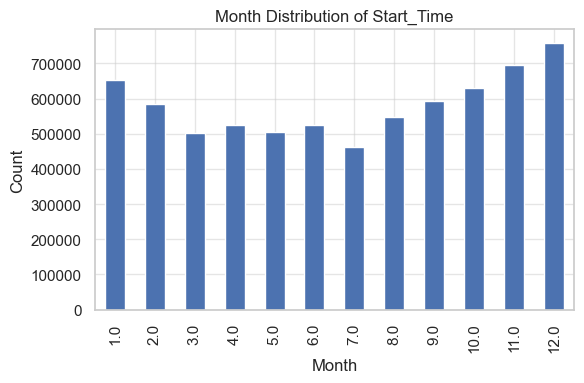

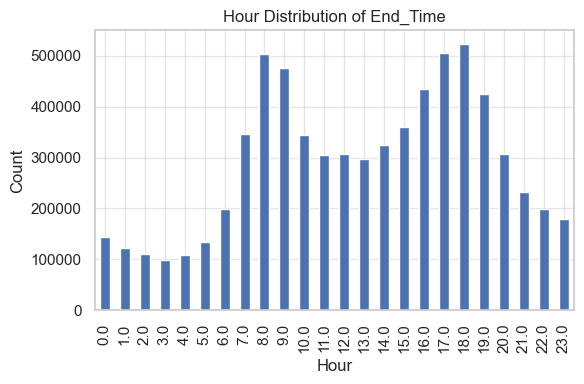

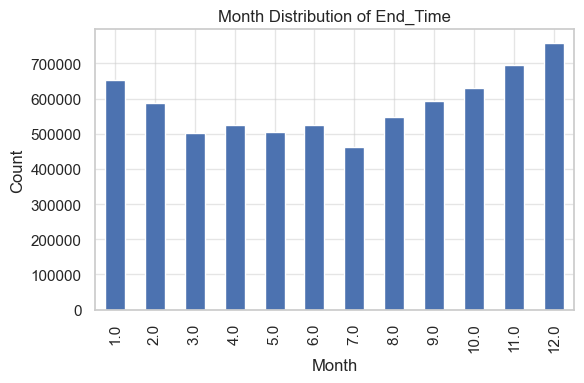

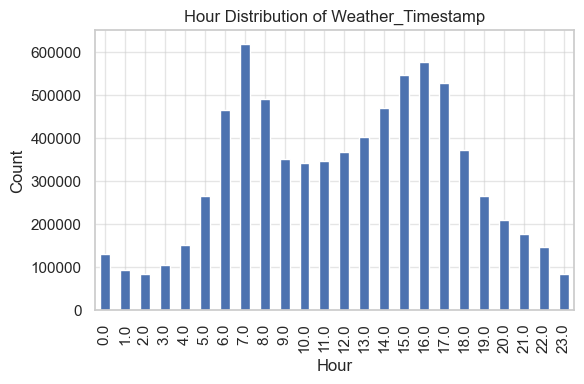

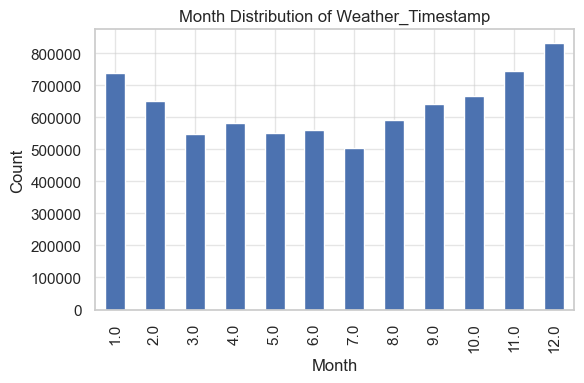

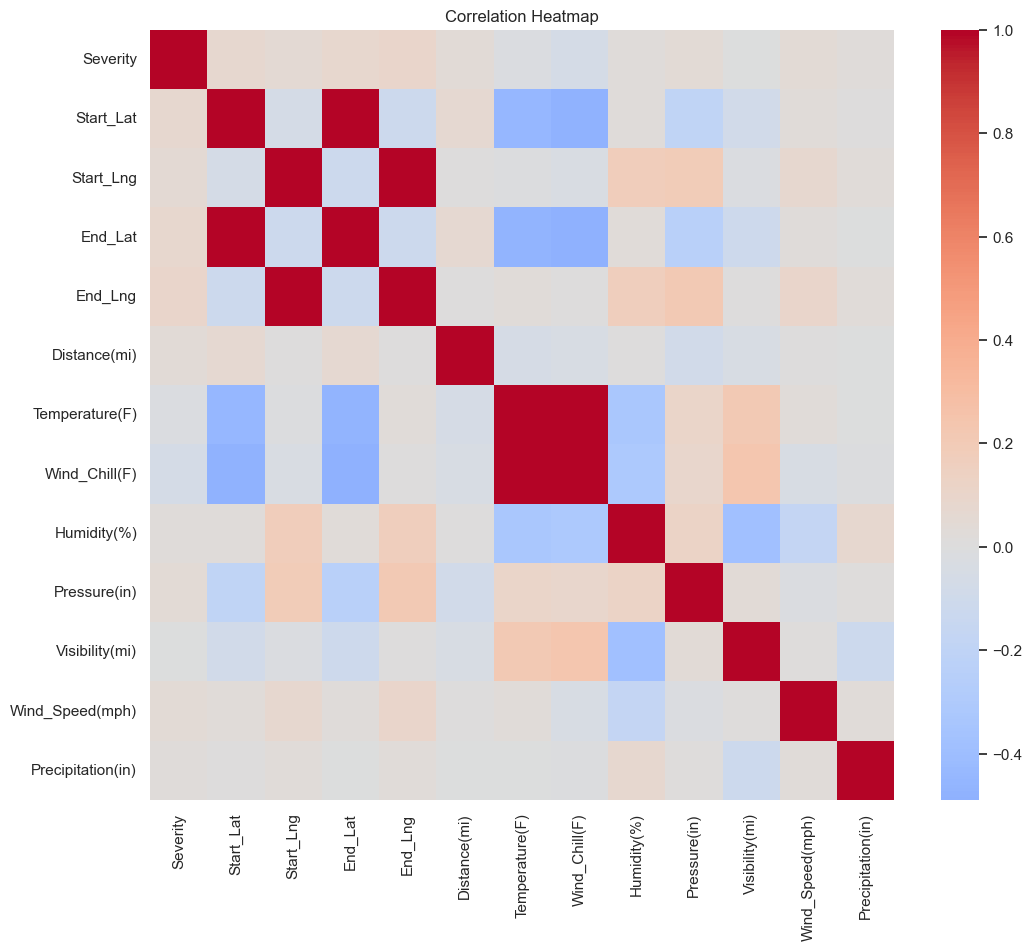

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# --- LOAD DATA ---
# df = pd.read_csv("US_Accidents.csv")

# --- PARSE DATETIME (IMPORTANT) ---
time_cols = ['Start_Time', 'End_Time', 'Weather_Timestamp']
for col in time_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# --- TYPE DETECTION ---
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# detect boolean-like columns
bool_cols = [col for col in df.columns if df[col].nunique() == 2]

# --- NUMERIC DISTRIBUTIONS (FAST) ---
for col in numeric_cols:
    plt.figure(figsize=(6,4))

    # Use matplotlib histogram (faster than seaborn KDE)
    plt.hist(df[col].dropna(), bins=50)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# --- CATEGORICAL DISTRIBUTIONS (TOP-K ONLY) ---
MAX_CATS = 20

for col in categorical_cols:
    plt.figure(figsize=(8,4))

    vc = df[col].value_counts(dropna=True)
    vc = vc.head(MAX_CATS)

    plt.barh(vc.index[::-1], vc.values[::-1])

    plt.title(f'Top {MAX_CATS} Categories of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# --- BOOLEAN FEATURES ---
for col in bool_cols:
    plt.figure(figsize=(4,3))

    df[col].value_counts().plot(kind='bar')

    plt.title(f'Binary Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# --- DATETIME DISTRIBUTIONS ---
for col in time_cols:
    if col in df.columns:

        # Hour
        plt.figure(figsize=(6,4))
        df[col].dt.hour.value_counts().sort_index().plot(kind='bar')
        plt.title(f'Hour Distribution of {col}')
        plt.xlabel('Hour')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

        # Month
        plt.figure(figsize=(6,4))
        df[col].dt.month.value_counts().sort_index().plot(kind='bar')
        plt.title(f'Month Distribution of {col}')
        plt.xlabel('Month')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

# --- CORRELATION HEATMAP ---
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()